In [11]:
import os
import sys
import torch
from tqdm import tqdm
from dotenv import load_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader

load_dotenv()
sys.path.append(os.getenv("ROOT_PATH"))
import miso_utils.datasets as mud

def show_tensor_image(tensor):
 
    image = tensor.cpu().clone().detach()
    image = image.permute(1, 2, 0)
    
    if image.min() < 0 or image.max() > 1:
        image = (image - image.min()) / (image.max() - image.min())
    
    plt.imshow(image)
    plt.axis('off')
    plt.show()

## ANN Model

In [12]:
# class ANNModel(nn.Module):
#     def __init__(self, input_dim=1024):
#         super(ANNModel, self).__init__()
        
#         # A simple architecture: Input -> Hidden -> Output
#         self.network = nn.Sequential(
#             nn.Linear(input_dim, 512),
#             nn.ReLU(),
#             nn.Dropout(0.2),      # Helps prevent overfitting on smaller datasets
#             nn.Linear(512, 256),
#             nn.ReLU(),
#             nn.Linear(256, 10), 
#             nn.Sigmoid(),    # Single output for binary classification
#             nn.Linear(10, 1),
#             # Note: No Sigmoid here if using nn.BCEWithLogitsLoss (recommended)
#         )

#     def forward(self, x):
#         return self.network(x)

#     def give_last_hidden(self, x):
#         for i in range(7):
#             x = self.network[i](x)
#         return x

class ANNModel(nn.Module):
    def __init__(self, input_dim=1280):
        super(ANNModel, self).__init__()
        
        # A simple architecture: Input -> Hidden -> Output
        self.network = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128), 
            nn.ReLU(),
            nn.Linear(128, 10), 
            nn.Sigmoid(),    # Single output for binary classification
            nn.Linear(10, 1),
            # Note: No Sigmoid here if using nn.BCEWithLogitsLoss (recommended)
        )

    def forward(self, x):
        return self.network(x)

    def give_last_hidden(self, x):
        for i in range(9):
            x = self.network[i](x)
        return x

## Neural Descion Tree

In [13]:
class NeuralDesicionTreeNode():
    def __init__(self, BaseModelClass):
        self.BaseModelClass = BaseModelClass
        self.model = BaseModelClass()

        self.left = None
        self.right = None
        self.isLeaf = False

    def train_node(self, train_loader, val_loader=None, epochs=40, lr=1e-3 * 5, device="cuda", save_path="./temp/", patience=3):
        self.model.to(device)
        os.makedirs(save_path, exist_ok=True)

        criterion = nn.BCEWithLogitsLoss(reduction='sum')
        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        # Initialize the scheduler: factor=0.5 halves the LR, mode='min' watches for loss decreasing
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience)

        best_val_acc = 0.0
        print(f"Starting training on {device}...")

        for epoch in range(epochs):
            self.model.train()
            train_loss, train_correct, train_total = 0.0, 0, 0

            pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
            for batch in pbar:
                features = batch['X'].to(device)
                labels = batch['y'].to(device).float()

                optimizer.zero_grad()
                logits = self.model(features.float()).squeeze()

                # Handle single-item batch squeezing issue
                if logits.dim() == 0: logits = logits.unsqueeze(0) 

                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                train_total += labels.size(0)

                preds = (torch.sigmoid(logits) > 0.5).float()
                train_correct += (preds == labels).sum().item()

                pbar.set_postfix(
                    avg_loss=f"{train_loss/train_total:.4f}", 
                    acc=f"{100*train_correct/train_total:.2f}%"
                )

            epoch_train_loss = train_loss / train_total

            # --- VALIDATION PHASE ---
            if val_loader is not None:
                self.model.eval()
                val_loss, val_total, val_correct = 0.0, 0, 0

                with torch.no_grad():
                    vbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
                    for batch in vbar:
                        features = batch['X'].to(device)
                        labels = batch['y'].to(device).float()

                        logits = self.model(features.float()).squeeze()
                        if logits.dim() == 0: logits = logits.unsqueeze(0)

                        loss = criterion(logits, labels)

                        val_loss += loss.item()
                        val_total += labels.size(0)

                        preds = (torch.sigmoid(logits) > 0.5).float()
                        val_correct += (preds == labels).sum().item()

                        vbar.set_postfix(
                            avg_loss=f"{val_loss/val_total:.4f}", 
                            acc=f"{100*val_correct/val_total:.2f}%"
                        )

                epoch_val_acc = 100 * val_correct / val_total
                epoch_val_loss = val_loss / val_total

                scheduler.step(epoch_train_loss)

                if epoch_val_acc >= best_val_acc:
                    best_val_acc = epoch_val_acc
                    torch.save(self.model.state_dict(), save_path + 'best_miso_model.pt')
            else:
                # Fallback: Save latest epoch and step scheduler on train loss
                torch.save(self.model.state_dict(), save_path + 'best_miso_model.pt')
                scheduler.step(epoch_train_loss)

            # Print current Learning Rate so you can track the scheduler's behavior
            current_lr = optimizer.param_groups[0]['lr']
            print(f"End of Epoch {epoch+1}. Current Learning Rate: {current_lr:.6f}")

        # Load best model weights before exiting
        checkpoint = torch.load(save_path + 'best_miso_model.pt', map_location=device)
        self.model.load_state_dict(checkpoint)
       
    def _entropy(self, y):
        if len(y) == 0: return 0.0
        p = (y == 1).sum().float() / len(y)
        if p == 0 or p == 1: return 0.0
        return -p * torch.log2(p) - (1 - p) * torch.log2(1 - p)

    def _split_indices(self, dataset, feature_idx, threshold, device="cuda"):
        left_indices, right_indices = [], []
        if len(dataset) == 0: return left_indices, right_indices
        
        self.model.eval()
        loader = DataLoader(dataset, batch_size=64, shuffle=False)
        current_idx = 0
        
        with torch.no_grad():
            for batch in loader:
                x = batch['X'].to(device)
                hidden = self.model.give_last_hidden(x.float())
                
                condition = hidden[:, feature_idx] <= threshold
                
                for val in condition:
                    if val.item():
                        left_indices.append(current_idx)
                    else:
                        right_indices.append(current_idx)
                    current_idx += 1
                    
        return left_indices, right_indices

    def fit(self, train_dataset, val_dataset,max_bins = 8, current_depth=0, max_depth=3, min_samples_split=20, device="cuda"):

        # --- 1. BASE CASES ---
        labels = torch.tensor([train_dataset[i]['y'] for i in range(len(train_dataset))])
        self.is_pure = len(torch.unique(labels)) == 1
        
        if self.is_pure or current_depth >= max_depth or len(train_dataset) < min_samples_split:
            self.isLeaf = True
            if self.is_pure: 
                self.label = train_dataset[0]['y']
            else:
                # Majority voting if not pure but forced to be a leaf
                self.label = torch.mode(labels).values.item()
            
            self.model = None
            return

        # --- 2. TRAIN CURRENT NODE ---
        batch_size = 256
        train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
        if len(val_dataset) > 10: 
            val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
        else:
            val_loader = None 
            
        self.train_node(train_loader, val_loader, device=device)

        # --- 3. GET REPRESENTATIONS & CALCULATE SPLIT ---
        self.model.eval()
        all_hidden = []
        with torch.no_grad():
            for batch in DataLoader(train_dataset, batch_size=64, shuffle=False):
                h = self.model.give_last_hidden(batch['X'].float().to(device))
                all_hidden.append(h.cpu())
                
        vectors = torch.cat(all_hidden, dim=0)
        
        best_ig = -1.0
        best_feature_idx = None
        best_threshold = None
        base_entropy = self._entropy(labels)

        # Iterate through features to find best Information Gain
        for feature_idx in range(vectors.shape[1]):
            feature_vals = vectors[:, feature_idx].float() # Quantile requires float32
            
            # --- BINNING LOGIC ---
            unique_vals = torch.unique(feature_vals)
            
            if len(unique_vals) <= max_bins:
                thresholds = unique_vals
            else:
                # Generate quantiles (e.g., for max_bins=10, we want the 10th, 20th... 90th percentiles)
                # We slice [1:-1] to avoid testing the absolute min and max, which create empty splits
                q = torch.linspace(0, 1, steps=max_bins + 2)[1:-1] 
                
                # Calculate thresholds and call unique() again in case multiple quantiles 
                # fall on the exact same value (happens in dense data clusters)
                thresholds = torch.unique(torch.quantile(feature_vals, q))
            # ---------------------
            
            for t in thresholds:
                left_mask = feature_vals <= t
                right_mask = ~left_mask
                
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue
                    
                y_left = labels[left_mask]
                y_right = labels[right_mask]
                
                p_left = len(y_left) / len(labels)
                p_right = len(y_right) / len(labels)
                
                ig = base_entropy - (p_left * self._entropy(y_left) + p_right * self._entropy(y_right))
                
                if ig > best_ig:
                    best_ig = ig
                    best_feature_idx = feature_idx
                    best_threshold = t

        # Infinite Recursion Safety Net
        if best_ig <= 0:
            print(" Information Gain < 0")
            self.isLeaf = True
            self.label = torch.mode(labels).values.item()
            return

        self.split_feature_idx = best_feature_idx
        self.split_threshold = best_threshold.to(device)

        # --- 4. ROUTE DATASETS ---
        train_left_idx, train_right_idx = self._split_indices(train_dataset, best_feature_idx, best_threshold, device)
        val_left_idx, val_right_idx = self._split_indices(val_dataset, best_feature_idx, best_threshold, device)

        # --- 5. RECURSE ---
        self.left = NeuralDesicionTreeNode(self.BaseModelClass)
        self.right = NeuralDesicionTreeNode(self.BaseModelClass)
        
        self.left.fit(torch.utils.data.Subset(train_dataset, train_left_idx), 
                      torch.utils.data.Subset(val_dataset, val_left_idx),max_bins,
                      current_depth + 1, max_depth, min_samples_split, device)
                      
        self.right.fit(torch.utils.data.Subset(train_dataset, train_right_idx), 
                       torch.utils.data.Subset(val_dataset, val_right_idx),max_bins, 
                       current_depth + 1, max_depth, min_samples_split, device)
    
    def predict(self, x, device="cuda"):
        """
        Classifies a batch of inputs.
        Args:
            x: Tensor of inputs [batch_size, ...]
        Returns:
            Tensor of predicted labels [batch_size]
        """
        batch_size = x.shape[0]
        preds = torch.zeros(batch_size, device=device)
        
        # --- 1. BASE CASE: LEAF NODE ---
        if self.isLeaf:
            # Return a tensor filled with this leaf's label
            return preds.fill_(self.label)
            
        # --- 2. ROUTING ---
        self.model.eval()
        with torch.no_grad():
            x = x.to(device)
            hidden = self.model.give_last_hidden(x.float())
            
            # Determine which samples go left vs right
            left_mask = hidden[:, self.split_feature_idx] <= self.split_threshold
            right_mask = ~left_mask
            
            # --- 3. RECURSE & RECOMBINE ---
            if left_mask.any():
                # Pass only the subset of 'x' that belongs to the left child
                preds[left_mask] = self.left.predict(x[left_mask], device)
                
            if right_mask.any():
                # Pass only the subset of 'x' that belongs to the right child
                preds[right_mask] = self.right.predict(x[right_mask], device)
                
        return preds

In [14]:
from torch.utils.data import Dataset
class NeuralTreeDataset(Dataset):
    def __init__(self):
        super().__init__()
        ...

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return {
            "X": self.data[index],
            "y": self.labels[index],
        }

In [15]:
class ClipBertDataset(NeuralTreeDataset):
    def __init__(self,Clip_Path,Bert_Path):
        super().__init__()

        clip_dataset = torch.load(Clip_Path,weights_only = False)
        bert_dataset = torch.load(Bert_Path,weights_only = False)

        self.labels = [clip_dataset[i]["indian_label"] for i in range(len(clip_dataset))]
        self.data = [torch.concat((clip_dataset[i]["embedding"],bert_dataset[i]["embedding"])) for i in range(len(clip_dataset))]

In [16]:
ClipBertTrain = ClipBertDataset("./datasets/clip_image/train.pt","./datasets/bert-base-uncased/train.pt")
ClipBertVal = ClipBertDataset("./datasets/clip_image/val.pt","./datasets/bert-base-uncased/val.pt")

In [17]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# 1. Get indices and labels
indices = list(range(len(ClipBertTrain)))
labels = ClipBertTrain.labels 

# 2. Perform the stratified split
train_indices, val_indices = train_test_split(
    indices, 
    test_size=0.2, 
    stratify=labels, 
    random_state=42 # Set a seed for reproducibility
)

# 3. Create the PyTorch Subsets
tree_train_subset = Subset(ClipBertTrain, train_indices)
tree_val_subset = Subset(ClipBertTrain, val_indices)

# Verify the lengths
print(f"Original size: {len(ClipBertTrain)}")
print(f"Train subset size: {len(tree_train_subset)}")
print(f"Val subset size: {len(tree_val_subset)}")

Original size: 9395
Train subset size: 7516
Val subset size: 1879


In [18]:
treeClassifer = NeuralDesicionTreeNode(BaseModelClass = ANNModel)
treeClassifer.fit(tree_train_subset,tree_val_subset,min_samples_split=20,max_depth=8,max_bins=20)

Starting training on cuda...


Epoch 1/40 [Val]: 100%|██████████| 8/8 [00:00<00:00, 172.88it/s, acc=70.41%, avg_loss=0.5730]


End of Epoch 1. Current Learning Rate: 0.005000


Epoch 2/40 [Val]: 100%|██████████| 8/8 [00:00<00:00, 190.08it/s, acc=75.78%, avg_loss=0.5201]


End of Epoch 2. Current Learning Rate: 0.005000


...

End of Epoch 38. Current Learning Rate: 0.000020


Epoch 39/40 [Val]: 100%|██████████| 6/6 [00:00<00:00, 154.46it/s, acc=82.73%, avg_loss=0.4715]


End of Epoch 39. Current Learning Rate: 0.000020


Epoch 40/40 [Val]: 100%|██████████| 6/6 [00:00<00:00, 431.75it/s, acc=82.73%, avg_loss=0.4715]


End of Epoch 40. Current Learning Rate: 0.000010
 Information Gain < 0


Evaluating tree...
Overall Accuracy: 74.83%
Macro F1 Score: 0.6814


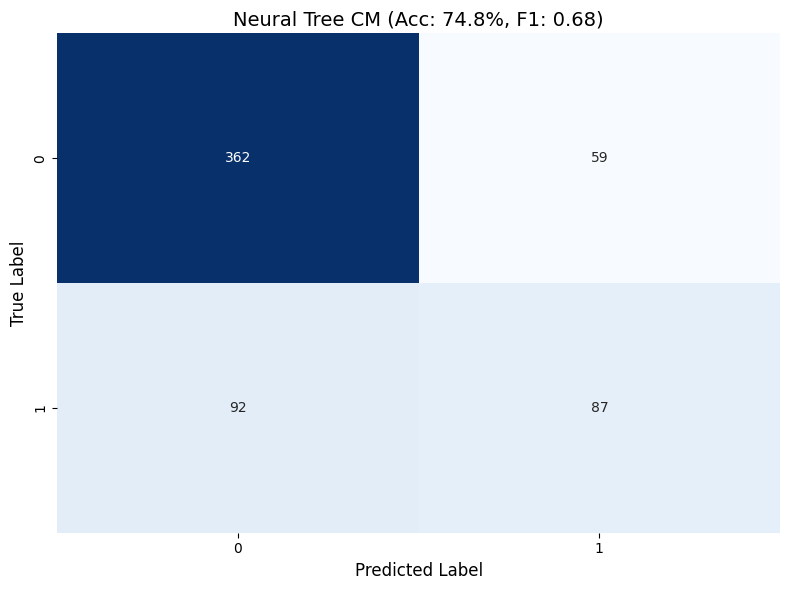

(0.7483333333333333,
 0.6814065934065934,
 array([[362,  59],
        [ 92,  87]]))

In [21]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from torch.utils.data import DataLoader

def evaluate_and_plot(tree_root, dataset, batch_size=64, device="cuda"):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_preds = []
    all_labels = []

    print("Evaluating tree...")
    with torch.no_grad():
        for batch in loader:
            x = batch['X'].to(device)
            labels = batch['y'].cpu().numpy()
            
            preds = tree_root.predict(x, device=device).cpu().numpy()
            
            all_preds.extend(preds)
            all_labels.extend(labels)

    # 1. Calculate Metrics
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    
    print(f"Overall Accuracy: {acc * 100:.2f}%")
    print(f"Macro F1 Score: {macro_f1:.4f}")

    # 2. Generate Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    # 3. Plotting
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Neural Tree CM (Acc: {acc*100:.1f}%, F1: {macro_f1:.2f})', fontsize=14)
    plt.tight_layout() # Added for better mobile/small screen rendering
    plt.show()

    return acc, macro_f1, cm

evaluate_and_plot(treeClassifer,ClipBertVal)

Epoch 1/40 | Train Loss: 0.6342 | Train Acc: 0.6678 | Train F1: 0.5112 || Val Loss: 0.6088 | Val Acc: 0.7200 | Val F1: 0.5512
Epoch 2/40 | Train Loss: 0.5729 | Train Acc: 0.7607 | Train F1: 0.6652 || Val Loss: 0.5549 | Val Acc: 0.7583 | Val F1: 0.6508
Epoch 3/40 | Train Loss: 0.5251 | Train Acc: 0.7881 | Train F1: 0.7185 || Val Loss: 0.5250 | Val Acc: 0.7767 | Val F1: 0.7035
Epoch 4/40 | Train Loss: 0.4954 | Train Acc: 0.8036 | Train F1: 0.7439 || Val Loss: 0.4955 | Val Acc: 0.7917 | Val F1: 0.7363
Epoch 5/40 | Train Loss: 0.4657 | Train Acc: 0.8227 | Train F1: 0.7720 || Val Loss: 0.5121 | Val Acc: 0.7700 | Val F1: 0.7060
Epoch 6/40 | Train Loss: 0.4460 | Train Acc: 0.8321 | Train F1: 0.7843 || Val Loss: 0.4837 | Val Acc: 0.7900 | Val F1: 0.7336
Epoch 7/40 | Train Loss: 0.4202 | Train Acc: 0.8465 | Train F1: 0.8059 || Val Loss: 0.4813 | Val Acc: 0.8000 | Val F1: 0.7357
Epoch 8/40 | Train Loss: 0.3991 | Train Acc: 0.8589 | Train F1: 0.8213 || Val Loss: 0.5058 | Val Acc: 0.7783 | Val F1:

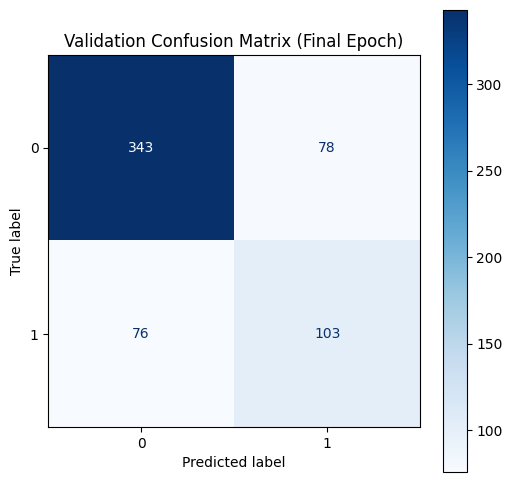

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def train_loop(model, train_dataset, val_dataset, epochs=10, batch_size=32, lr=1e-3):
    # Setup device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    # Setup DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Loss and Optimizer
    criterion = nn.BCEWithLogitsLoss() 
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Track final validation targets and predictions for the confusion matrix
    final_val_true = []
    final_val_pred = []
    
    for epoch in range(epochs):
        # -----------------
        #  Training Phase
        # -----------------
        model.train()
        running_train_loss = 0.0
        train_true = []
        train_pred = []
        
        for batch in train_loader:
            X = batch["X"].to(device)
            y = batch["y"].to(device).float().view(-1, 1) 
            
            optimizer.zero_grad()
            
            outputs = model(X)
            loss = criterion(outputs, y)
            
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * X.size(0)
            
            # Convert logits to binary predictions. (logit > 0.0 is equivalent to probability > 0.5)
            preds = (outputs > 0.0).float()
            
            # Store for metrics
            train_true.extend(y.cpu().numpy())
            train_pred.extend(preds.detach().cpu().numpy())
            
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_true, train_pred)
        train_f1 = f1_score(train_true, train_pred, average='macro')
        
        # -----------------
        # Validation Phase
        # -----------------
        model.eval()
        running_val_loss = 0.0
        val_true = []
        val_pred = []
        
        with torch.no_grad():
            for batch in val_loader:
                X = batch["X"].to(device)
                y = batch["y"].to(device).float().view(-1, 1)
                
                outputs = model(X)
                loss = criterion(outputs, y)
                
                running_val_loss += loss.item() * X.size(0)
                
                preds = (outputs > 0.0).float()
                val_true.extend(y.cpu().numpy())
                val_pred.extend(preds.cpu().numpy())
                
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_acc = accuracy_score(val_true, val_pred)
        val_f1 = f1_score(val_true, val_pred, average='macro')
        
        # Save the last epoch's validation data for the confusion matrix
        if epoch == epochs - 1:
            final_val_true = val_true
            final_val_pred = val_pred
        
        # Print metrics
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} || "
              f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    # -------------------------
    # Confusion Matrix Plotting
    # -------------------------
    cm = confusion_matrix(final_val_true, final_val_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    # Plotting adjustments
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title("Validation Confusion Matrix (Final Epoch)")
    plt.show()

# Example execution
model = ANNModel()
train_loop(model, ClipBertTrain, ClipBertVal, epochs=40, batch_size=128, lr=1e-4 * 5)